## Build dataset

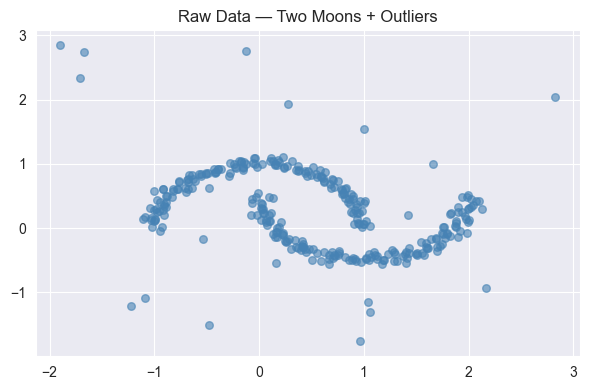

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
from sklearn.datasets import make_moons, make_blobs

np.random.seed(42)

# Create dataset with irregular shapes + outliers
# make_moons creates two interleaving half-circles
# K-Means fails on this, DBSCAN handles it perfectly
X_moons, _ = make_moons(n_samples=300, noise=0.05, random_state=42)

# Add some random outliers
outliers = np.random.uniform(low=-2, high=3, size=(20, 2))
X = np.vstack([X_moons, outliers])

plt.figure(figsize=(6, 4))
plt.scatter(X[:, 0], X[:, 1], s=30, alpha=0.6, color='steelblue')
plt.title("Raw Data — Two Moons + Outliers")
plt.tight_layout()
plt.show()

## 1- Scale Data

In [3]:
scaler   = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Scaling is important for DBSCAN
# eps is measured in actual distance units
# if features have very different scales:
#   one feature dominates the distance calculation
#   eps becomes meaningless
# After scaling: all features contribute equally to distance

## 2 — Find Optimal eps (K-Distance Plot

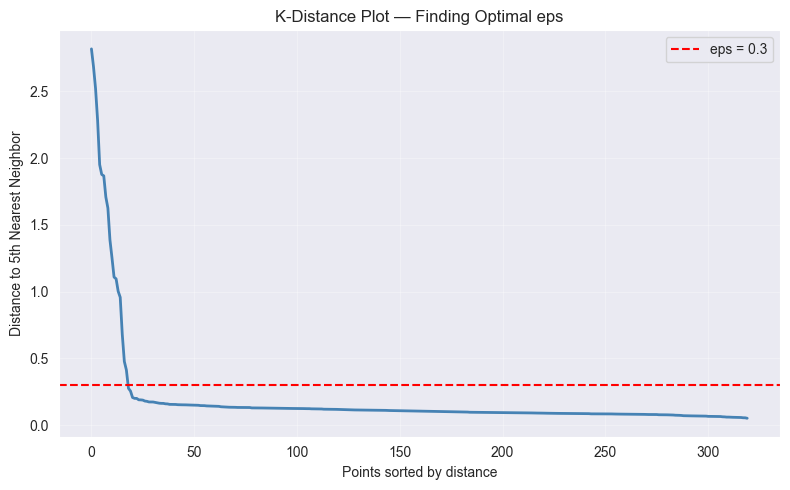

In [4]:
from sklearn.neighbors import NearestNeighbors

# Strategy: for each point, find distance to its k-th nearest neighbor
# k = min_samples - 1
# Sort distances and plot → look for the "elbow"
# The elbow = good eps value

min_samples = 5
neighbors   = NearestNeighbors(n_neighbors=min_samples)
neighbors.fit(X_scaled)

distances, _ = neighbors.kneighbors(X_scaled)
# distances[:, -1] = distance to the k-th nearest neighbor for each point

k_distances = np.sort(distances[:, -1])[::-1]
# sort descending so elbow is visible

plt.figure(figsize=(8, 5))
plt.plot(k_distances, color='steelblue', linewidth=2)
plt.xlabel("Points sorted by distance")
plt.ylabel(f"Distance to {min_samples}th Nearest Neighbor")
plt.title("K-Distance Plot — Finding Optimal eps")
plt.axhline(y=0.3, color='red', linestyle='--', label='eps = 0.3')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Sharp elbow in the curve = good eps
# Points above elbow = outliers (sparse, far from neighbors)
# Points below elbow = core/border points (dense)

## 3 — Fit DBSCAN

In [5]:
dbscan = DBSCAN(
    eps         = 0.3,
    # ↑ neighborhood radius
    #   too small → everything becomes noise
    #   too large → everything merges into one cluster

    min_samples = 5,
    # ↑ minimum points to be a core point
    #   too small → noise points become clusters
    #   too large → real clusters labeled as noise

    metric      = 'euclidean'
    # ↑ distance metric
    #   can also use: manhattan, cosine, etc.
)

labels = dbscan.fit_predict(X_scaled)
# labels = array of cluster assignments
# -1 = noise point
# 0, 1, 2, ... = cluster IDs

# Analyze results
n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
n_noise    = list(labels).count(-1)

print(f"Clusters found : {n_clusters}")
print(f"Noise points   : {n_noise}")
print(f"Cluster labels : {set(labels)}")

Clusters found : 2
Noise points   : 18
Cluster labels : {np.int64(0), np.int64(1), np.int64(-1)}


## 4 — Visualize Results

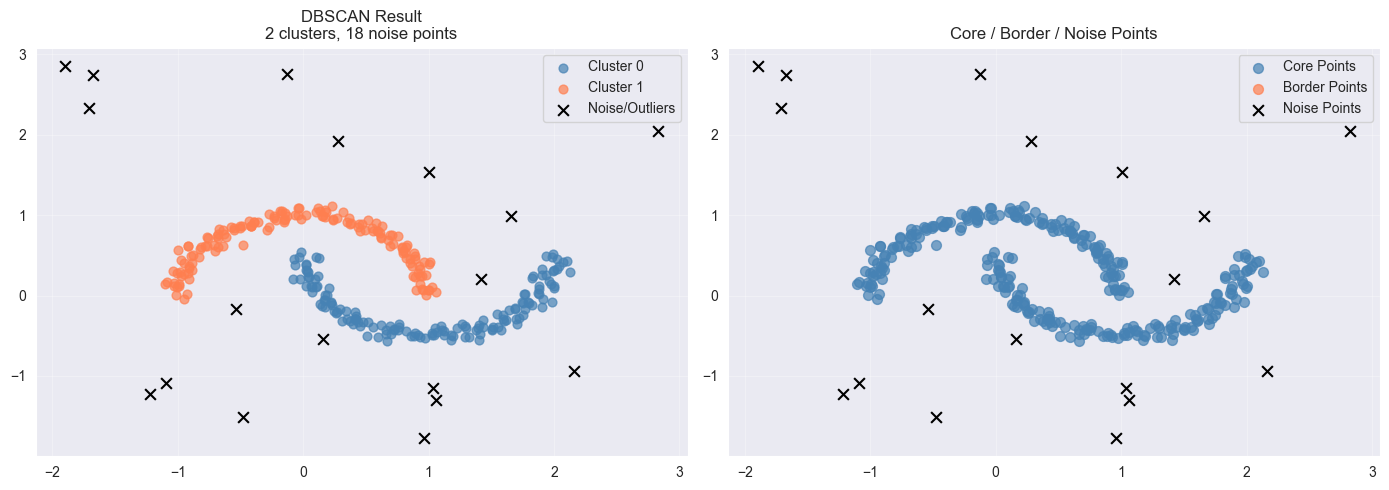

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Plot 1: DBSCAN result ──────────────────────────────────
unique_labels = set(labels)
colors = ['steelblue', 'coral', 'mediumseagreen',
          'purple', 'orange', 'brown']

for label in unique_labels:
    mask = labels == label

    if label == -1:
        # Noise points → black X markers
        axes[0].scatter(
            X[mask, 0], X[mask, 1],
            c='black', marker='x', s=60,
            linewidths=1.5, label='Noise/Outliers'
        )
    else:
        axes[0].scatter(
            X[mask, 0], X[mask, 1],
            c=colors[label], s=40, alpha=0.7,
            label=f'Cluster {label}'
        )

axes[0].set_title(f"DBSCAN Result\n{n_clusters} clusters, {n_noise} noise points")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# ── Plot 2: Core, Border, Noise points ────────────────────
# dbscan.core_sample_indices_ = indices of core points
core_mask   = np.zeros(len(X), dtype=bool)
core_mask[dbscan.core_sample_indices_] = True

border_mask = (~core_mask) & (labels != -1)
noise_mask  = labels == -1

axes[1].scatter(X[core_mask,   0], X[core_mask,   1],
                c='steelblue', s=50,  alpha=0.7, label='Core Points')
axes[1].scatter(X[border_mask, 0], X[border_mask, 1],
                c='coral',     s=50,  alpha=0.7, label='Border Points')
axes[1].scatter(X[noise_mask,  0], X[noise_mask,  1],
                c='black',     s=60,  marker='x',
                linewidths=1.5,       label='Noise Points')

axes[1].set_title("Core / Border / Noise Points")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 5 — Effect of eps and min_samples

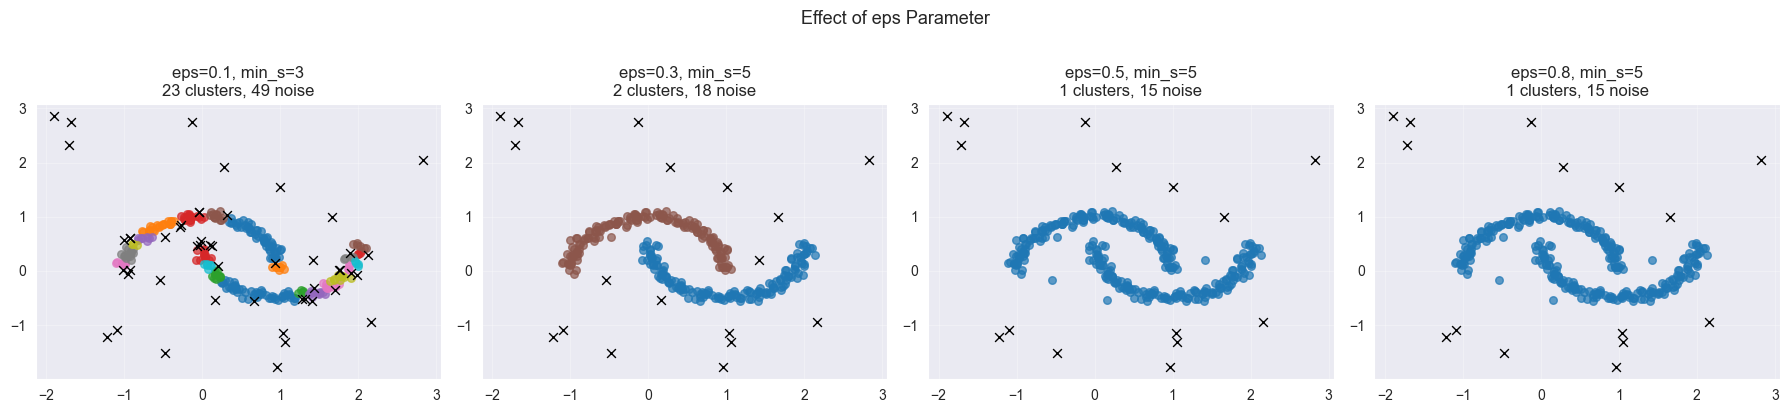

In [7]:
# See how results change with different parameters
eps_values         = [0.1, 0.3, 0.5, 0.8]
min_samples_values = [3,   5,   5,   5  ]

fig, axes = plt.subplots(1, 4, figsize=(18, 4))

for ax, eps, ms in zip(axes, eps_values, min_samples_values):
    db     = DBSCAN(eps=eps, min_samples=ms)
    lbs    = db.fit_predict(X_scaled)

    n_cls  = len(set(lbs)) - (1 if -1 in lbs else 0)
    n_nse  = list(lbs).count(-1)

    unique = set(lbs)
    colors = plt.cm.tab10(np.linspace(0, 1, max(len(unique), 1)))

    for i, label in enumerate(unique):
        mask = lbs == label
        if label == -1:
            ax.scatter(X[mask,0], X[mask,1],
                       c='black', marker='x', s=40, linewidths=1)
        else:
            ax.scatter(X[mask,0], X[mask,1],
                       color=colors[i], s=30, alpha=0.7)

    ax.set_title(f"eps={eps}, min_s={ms}\n"
                 f"{n_cls} clusters, {n_nse} noise")
    ax.grid(True, alpha=0.3)

plt.suptitle("Effect of eps Parameter", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

# eps too small (0.1) → everything is noise
# eps just right (0.3) → correct clusters found
# eps too large (0.8) → clusters merge together